<a href="https://www.kaggle.com/code/adastroabyssosque/track-2-eda-xgboost-lstm?scriptVersionId=314575331" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# import libraries and data

In [1]:
!pip install scikeras keras-self-attention orjson missingno xgboost imblearn mlxtend

  Preparing metadata (setup.py) ... done
  Created wheel for keras-self-attention: filename=keras_self_attention-0.51.0-py3-none-any.whl size=18895 sha256=cd7e8e6139cd7d01b58c3f79fe6c53649dc14e745cb07f453ab701c7a7a2ac78
  Stored in directory: /root/.cache/pip/wheels/9a/9d/6e/09a0f61c2edeaea9f96fecdc67f31455c363bb44a4ddabe746
Successfully built keras-self-attention


In [2]:
import numpy as np 
import pandas as pd 
import orjson
from matplotlib import pyplot as plt
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
import os
import seaborn as sns
import missingno as msno
import math
from scipy.signal import find_peaks
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline, make_pipeline
from mlxtend.evaluate.time_series import GroupTimeSeriesSplit, print_split_info
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, GlobalAveragePooling1D
from scikeras.wrappers import KerasClassifier
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from keras_self_attention import SeqSelfAttention
import tensorflow as tf

2026-04-26 13:01:45.635442: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777208505.857566      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777208505.921686      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777208506.449355      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777208506.449395      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777208506.449398      22 computation_placer.cc:177] computation placer alr

In [3]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
track1 = pd.read_json('/kaggle/input/competitions/cvpr-2026-the-first-ai-children-challenge/track1_train.json')
track2 = pd.read_json('/kaggle/input/competitions/cvpr-2026-the-first-ai-children-challenge/track2_train.json')
global track1 
global track2

In [5]:
track1.head()

,patient_id,left,right
0,1,"{'1': 0, '2': 1, '3': 0, '4': 1, '5': 1, '6': ...","{'1': 0, '2': 1, '3': 0, '4': 1, '5': 1, '6': ..."
1,2,"{'1': 0, '2': 0, '3': 0, '4': 0, '5': 0, '6': ...","{'1': 1, '2': 1, '3': 0, '4': 0, '5': 1, '6': ..."
2,3,"{'1': 0, '2': 1, '3': 0, '4': 0, '5': 0, '6': ...","{'1': 1, '2': 1, '3': 0, '4': 0, '5': 1, '6': ..."
3,6,"{'1': 1, '2': 1, '3': 0, '4': 1, '5': 0, '6': ...","{'1': 0, '2': 0, '3': 0, '4': 1, '5': 0, '6': ..."
4,7,"{'1': 1, '2': 1, '3': 0, '4': 0, '5': 1, '6': ...","{'1': 1, '2': 1, '3': 0, '4': 0, '5': 1, '6': ..."


In [6]:
track2.head()

,patient_id,left,right
0,1,{'gait_subtype': 'type3'},{'gait_subtype': 'type3'}
1,5,{'gait_subtype': 'type3'},{'gait_subtype': 'type3'}
2,12,{'gait_subtype': 'type3'},{'gait_subtype': 'type3'}
3,18,{'gait_subtype': 'type2'},{'gait_subtype': 'type2'}
4,21,{'gait_subtype': 'type2'},{'gait_subtype': 'type2'}


# Metadata Preprocessing & EDA

In [7]:
def processing_metadata(track1 = track1, track2 = track2):
    for i in range(1, 18):
        track1['L'+str(i)] = track1['left'].apply(lambda x: x[str(i)])
        track1['R'+str(i)] = track1['right'].apply(lambda x: x[str(i)])
    track1_scored_item = ['L']
    track1 = track1.drop(['left', 'right'], axis=1)
    track2['Left_gait_subtype'] = track2['left'].map(lambda x: x['gait_subtype'])
    track2['Right_gait_subtype'] = track2['right'].map(lambda x: x['gait_subtype'])
    track2 = track2.drop(['left', 'right'], axis = 1)
    return track1, track2

In [8]:
track1, track2 = processing_metadata()
track1.head()

,patient_id,L1,R1,L2,R2,L3,R3,L4,R4,L5,...,L13,R13,L14,R14,L15,R15,L16,R16,L17,R17
0,1,0,0,1,1,0,0,1,1,1,...,0,0,1,0,1,1,1,1,0,0
1,2,0,1,0,1,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
2,3,0,1,1,1,0,0,0,0,0,...,0,0,0,1,1,0,1,1,0,1
3,6,1,0,1,0,0,0,1,1,0,...,0,0,0,0,1,1,0,1,0,0
4,7,1,1,1,1,0,0,0,0,1,...,0,0,1,0,1,1,1,1,1,1


In [9]:
track2.head()

,patient_id,Left_gait_subtype,Right_gait_subtype
0,1,type3,type3
1,5,type3,type3
2,12,type3,type3
3,18,type2,type2
4,21,type2,type2


# Q1: how many patients do we have

In [10]:
print(track1.shape[0])
print(track2.shape[0])

94
22


## Q2: do patients have the same gait type at left and right?

In [11]:
track2.loc[track2['Left_gait_subtype']!=track2['Right_gait_subtype']]

,patient_id,Left_gait_subtype,Right_gait_subtype
11,32,type2,type3
15,48,type1,type3


## Q3: how many patients have left EVGS scoring different from their right?

In [12]:
def sum_svgs_per_leg(track1 = track1):
    left = ['L'+str(i) for i in range(1, 18)]
    right = ['R'+str(i) for i in range(1, 18)]
    track1['Left_SVGS_Score'] = track1.loc[:,left].sum(axis = 1)
    track1['Right_SVGS_Score'] = track1.loc[:,right].sum(axis = 1)
    return track1

In [13]:
track1 = sum_svgs_per_leg()

In [14]:
track1[['Left_SVGS_Score', 'Right_SVGS_Score']].describe()

,Left_SVGS_Score,Right_SVGS_Score
count,94.000000,94.000000
mean,5.840426,5.989362
std,3.312742,3.227885
min,1.000000,0.000000
25%,3.000000,3.000000
50%,5.000000,6.000000
75%,8.000000,8.000000
max,13.000000,14.000000


In [15]:
track2.Left_gait_subtype.value_counts()

Left_gait_subtype
type2    8
type3    6
type1    6
WNL      1
type4    1
Name: count, dtype: int64

In [16]:
def get_id(s):
    num = 0
    for i in range(-1, -len(s)-1, -1):
        num+=10**(-i-1)*int(s[i])
    return(num)

In [17]:
# Define points2keep and cols outside so they are accessible
POINTS2KEEP = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 21, 19, 22, 20, 23]
COLS = ['patient_id','frame', 'nose', 'eye_l', 'eye_r', 'ear_l', 'ear_r',  'shoulder_l', 'shoulder_r', 'elbow_l', 'elbow_r', 
        'wrist_l', 'wrist_r',  'hip_l', 'hip_r', 'knee_l', 'knee_r', 'ankle_l', 'ankle_r', 'toe1_l', 'toe1_r', 'toe5_l',
        'toe5_r', 'heel_l',  'heel_r', 'nose_CI', 'eye_l_CI', 'eye_r_CI', 'ear_l_CI', 'ear_r_CI', 'shoulder_l_CI', 
        'shoulder_r_CI', 'hip_l_CI',  'hip_r_CI', 'elbow_l_CI', 'elbow_r_CI',  'wrist_l_CI', 'wrist_r_CI'
        'hip_r_CI', 'knee_l_CI', 'knee_r_CI','ankle_l_CI', 'ankle_r_CI','toe1_l_CI', 'toe1_r_CI', 'toe5_l_CI','toe5_r_CI', 
        'heel_l_CI', 'heel_r_CI', 'bbox']

def process_file(frame_path):
    try:
        # Extract patient_id from the path (e.g., .../dataset/001/front/...)
        patient_id = frame_path.parts[-3] 
        frame = frame_path.parts[-1].split('.')[0].split('_')[1]
        
        with open(frame_path, 'r') as f:
            data = orjson.loads(f.read())
            inst = data['instance_info'][0]
            
            kp = inst['keypoints']
            ks = inst['keypoint_scores']
            bbox = inst.get('gt_bbox_xywh_px')
            
            record = [get_id(patient_id), get_id(frame)+1]
            kp_row = []
            ks_row = []
            for idx in POINTS2KEEP: 
                if ks[idx-1]>0.3: 
                    kp_row.append(kp[idx-1])
                    ks_row.append(ks[idx-1])
                else: 
                     kp_row.append(None)
                     ks_row.append(None)
            record.extend(kp_row)
            record.extend(ks_row)
            record.append(bbox)
            return record
    except Exception as e:
        pass
        
def organize_df_parallel(side_filter):
    base_path = Path(r'/kaggle/input/datasets/adastroabyssosque/first-ai-for-children-competition-data/dataset/')
    
    print("Scanning for files...")
    # Get only the files that match your side filter
    all_frames = [f for f in base_path.rglob("*.json") if side_filter in f.parent.name.lower()]
    
    #print(f"Starting parallel processing of {len(all_frames)} files...")
    
    # ProcessPoolExecutor automatically uses all available CPU cores
    with ProcessPoolExecutor() as executor:
        results = list(executor.map(process_file, all_frames))
    
    # Filter out None results from errors and create DataFrame
    clean_results = [r for r in results if r is not None]
    return pd.DataFrame(clean_results, columns=COLS).sort_values(by = ['patient_id', 'frame'])

# Run it!
print('Gathering points from front view...')
front_df = organize_df_parallel('forward')
print('Gathering points from back veiw...')
back_df = organize_df_parallel('backward')
print('Gathering points from left view...')
left_df = organize_df_parallel('left')
print('Gathering points from right view...')
right_df = organize_df_parallel('right')

print(front_df.shape)
print(back_df.shape)
print(left_df.shape)
print(right_df.shape)

Gathering points from front view...
Scanning for files...
Gathering points from back veiw...
Scanning for files...
Gathering points from left view...
Scanning for files...
Gathering points from right view...
Scanning for files...
(90107, 49)
(83560, 49)
(88235, 49)
(77240, 49)


# Q4. Finally finished loading data, how does it look like?

In [18]:
CI = [ 'nose_CI', 'shoulder_l_CI', 
        'shoulder_r_CI', 'hip_l_CI', 'hip_r_CI', 'knee_l_CI', 'knee_r_CI','ankle_l_CI', 'ankle_r_CI',
        'toe1_l_CI', 'toe1_r_CI', 'toe5_l_CI','toe5_r_CI', 'heel_l_CI', 'heel_r_CI']

In [19]:
corrupted = front_df.loc[(front_df['patient_id']==53) & (front_df['frame']>1297)]
front_df.drop(corrupted.index, inplace=True)

In [20]:
def get_angle(u, v, o):
    if u is None or v is None or o is None: 
        return None
    o_x, o_y = o[0], o[1]
    u_x, u_y = u[0], u[1]
    v_x, v_y = v[0], v[1]
    u_x = u_x-o_x
    v_x = v_x-o_x
    u_y = u_y-o_y
    v_y = v_y-o_y

    u_dot_v = u_x*v_x+u_y*v_y
    mag_u = math.sqrt(u_x**2+u_y**2)
    mag_v = math.sqrt(v_x**2+v_y**2)
    if mag_u == 0 or mag_v == 0:
        return 0.0

    cos_theta = u_dot_v/(mag_u*mag_v)

    return math.degrees(math.acos(min(max(cos_theta, -1.0), 1.0) ))

In [21]:
def get_angles_df(df): 
    df['eye-hip-angle_l'] = df.apply(lambda x: get_angle(x['eye_l'], x['hip_l'], x['shoulder_l']), axis = 1)
    df['hip-ankle-angle_l'] = df.apply(lambda x: get_angle(x['hip_l'], x['ankle_l'], x['knee_l']), axis = 1)
    df['knee-toe1-angle_l'] = df.apply(lambda x: get_angle(x['knee_l'], x['toe1_l'], x['ankle_l']), axis = 1)
    df['knee-toe5-angle_l'] = df.apply(lambda x:  get_angle(x['knee_l'], x['toe5_l'], x['ankle_l']), axis = 1)
    df['knee-toe1-angle-heel_l'] = df.apply(lambda x: get_angle(x['knee_l'], x['toe1_l'], x['heel_l']), axis = 1)
    df['knee-toe5-angle-heel_l'] = df.apply(lambda x: get_angle(x['knee_l'], x['toe5_l'], x['heel_l']), axis = 1)
    df['eye-hip-angle_r'] = df.apply(lambda x: get_angle(x['eye_r'], x['hip_r'], x['shoulder_r']), axis = 1)
    df['hip-ankle-angle_r'] = df.apply(lambda x: get_angle(x['hip_r'], x['ankle_r'], x['knee_r']), axis = 1)
    df['knee-toe1-angle_r'] = df.apply(lambda x: get_angle(x['knee_r'], x['toe1_r'], x['ankle_r']), axis = 1)
    df['knee-toe5-angle_r'] = df.apply(lambda x:  get_angle(x['knee_r'], x['toe5_r'], x['ankle_r']), axis = 1)
    df['knee-toe1-angle-heel_r'] = df.apply(lambda x: get_angle(x['knee_r'], x['toe1_r'], x['heel_r']), axis = 1)
    df['knee-toe5-angle-heel_r'] = df.apply(lambda x: get_angle(x['knee_r'], x['toe5_r'], x['heel_r']), axis = 1)
    df['shoulder-wrist-angle_l'] = df.apply(lambda x: get_angle(x['shoulder_l'], x['wrist_l'], x['elbow_l']), axis = 1)
    df['shoulder-wrist-angle_r'] = df.apply(lambda x: get_angle(x['shoulder_r'], x['wrist_r'], x['elbow_r']), axis = 1)

    return df

In [22]:
front_df = get_angles_df(front_df)
back_df = get_angles_df(back_df)
left_df = get_angles_df(left_df)
right_df = get_angles_df(right_df)

In [23]:
def kpt_explode(df):
    kpt = ['nose', 'eye_l', 'eye_r', 'ear_l', 'ear_r',  'shoulder_l', 'shoulder_r', 'elbow_l', 'elbow_r', 
        'wrist_l', 'wrist_r',  'hip_l', 'hip_r', 'knee_l', 'knee_r', 'ankle_l', 'ankle_r', 'toe1_l', 'toe1_r', 'toe5_l',
        'toe5_r', 'heel_l',  'heel_r']
    for pt in kpt: 
        df[pt+'_x'] = df.apply(lambda x: (x[pt][0]-x['bbox'][0]) if x[pt] != None and x['bbox']!= None  else -1, axis = 1)
        df[pt+'_y'] = df.apply(lambda x: (x[pt][1]-x['bbox'][1]) if x[pt] != None and x['bbox']!= None else -1, axis = 1)

        df[pt+'_x'] = df.apply(lambda x: x[pt+'_x']/(x['bbox'][0]+x['bbox'][2]) if x['bbox']!=None and (x['bbox'][0]+x['bbox'][2])!=0 else x[pt+'_x'], axis = 1)
        df[pt+'_y'] = df.apply(lambda x: x[pt+'_y']/(x['bbox'][1]+x['bbox'][3]) if x['bbox']!=None and (x['bbox'][1]+x['bbox'][3])!=0 else x[pt+'_y'], axis = 1)
    df.drop(columns= kpt, axis = 1, inplace = True)
    return df

In [24]:
left_df_test = kpt_explode(left_df.copy())

In [25]:
patient1 = left_df_test.loc[left_df_test['patient_id']==1]

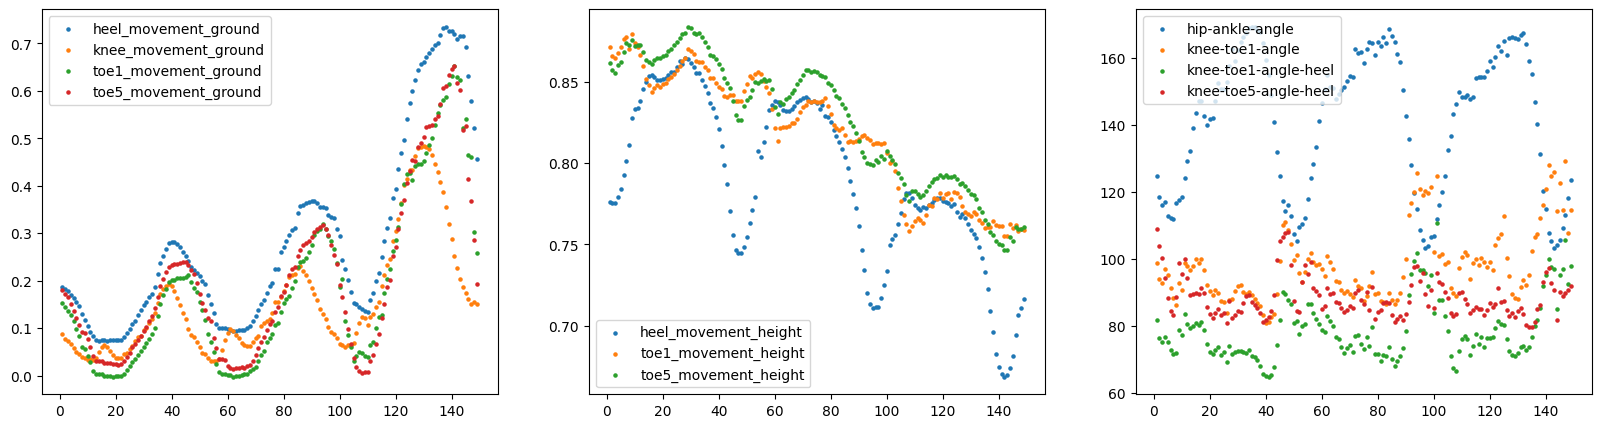

In [26]:
fig, ax = plt.subplots(1,3, figsize = (20, 5))
ax[0].scatter(x = patient1['frame'], y = patient1['heel_l_x'], label = 'heel_movement_ground', s = 5)
ax[0].scatter(x = patient1['frame'], y = patient1['knee_l_x'], label = 'knee_movement_ground', s = 5)
ax[0].scatter(x = patient1['frame'], y = patient1['toe1_l_x'], label = 'toe1_movement_ground', s = 5)
ax[0].scatter(x = patient1['frame'], y = patient1['toe5_l_x'], label = 'toe5_movement_ground', s = 5)
#ax[0].scatter(x = patient1['frame'], y = patient1['shoulder_l_x'], label = 'shoulder_movement_ground', s = 5)
ax[0].legend()

ax[1].scatter(x = patient1['frame'], y = patient1['heel_l_y'], label = 'heel_movement_height', s = 5)
#ax[1].scatter(x = patient1['frame'], y = patient1['knee_l_y'], label = 'knee_movement_height', s = 5)
ax[1].scatter(x = patient1['frame'], y = patient1['toe1_l_y'], label = 'toe1_movement_height', s = 5)
ax[1].scatter(x = patient1['frame'], y = patient1['toe5_l_y'], label = 'toe5_movement_height', s = 5)
ax[1].legend()

#ax[2].scatter(x = patient1['frame'], y = patient1['eye-hip-angle'], label = 'eye-hip-angle', s = 5)
ax[2].scatter(x = patient1['frame'], y = patient1['hip-ankle-angle_l'], label = 'hip-ankle-angle', s = 5)
ax[2].scatter(x = patient1['frame'], y = patient1['knee-toe1-angle_l'], label = 'knee-toe1-angle', s = 5)
#ax[2].scatter(x = patient1['frame'], y = patient1['knee-toe5-angle'], label = 'knee-toe5-angle', s = 5)
ax[2].scatter(x = patient1['frame'], y = patient1['knee-toe1-angle-heel_l'], label = 'knee-toe1-angle-heel', s = 5)
ax[2].scatter(x = patient1['frame'], y = patient1['knee-toe5-angle-heel_l'], label = 'knee-toe5-angle-heel', s = 5)
ax[2].legend()

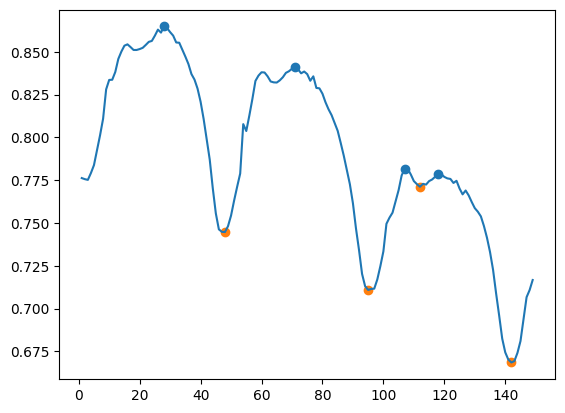

In [27]:
peaks, _ = find_peaks(patient1['heel_l_y'], width = 5)
low, _ = find_peaks(-patient1['heel_l_y'], width = 5)
fig, ax = plt.subplots()
ax.scatter(patient1['frame'].values[peaks], patient1['heel_l_y'].values[peaks], label = 'touching found')
ax.scatter(patient1['frame'].values[low], patient1['heel_l_y'].values[low], label = 'midstep')
ax.plot(patient1['frame'], patient1['heel_l_y'], label = 'heel_movement_height',)

In [28]:
def get_peak_vectorized(group):
    # Get peak indices for this patient's signal
    peaks_l, _ = find_peaks(group['heel_l_y'], width=5)
    lows_l, _ = find_peaks(-group['heel_l_y'], width=5)
    peaks_r, _ = find_peaks(group['heel_r_y'], width = 5)
    lows_r, _ = find_peaks(-group['heel_r_y'], width = 5)
    # Create a boolean mask initialized to False
    group['midstep_l'] = False
    group['touch_ground_l'] = False
    group['midstep_r'] = False
    group['touch_ground_r'] = False
    # Efficiently update peak positions using iloc
    if len(peaks_l) > 0:
        group.iloc[peaks_l, group.columns.get_loc('midstep_l')] = True
    if len(peaks_r) > 0:
        group.iloc[peaks_r, group.columns.get_loc('midstep_r')] = True
    if len(lows_l)>0: 
        group.iloc[lows_l, group.columns.get_loc('touch_ground_l')] = True
    if len(lows_r)>0: 
        group.iloc[lows_r, group.columns.get_loc('touch_ground_r')] = True
    # normalize frame
    group['frame'] = (group['frame']-group['frame'].min())/group['frame'].max()
    return group

In [29]:
front_df = kpt_explode(front_df)
back_df = kpt_explode(back_df)
left_df = kpt_explode(left_df)
right_df =kpt_explode(right_df)

In [30]:
front_df = front_df.groupby('patient_id', group_keys=False).apply(get_peak_vectorized)
back_df = back_df.groupby('patient_id', group_keys=False).apply(get_peak_vectorized)
left_df = left_df.groupby('patient_id', group_keys=False).apply(get_peak_vectorized)
right_df = right_df.groupby('patient_id', group_keys=False).apply(get_peak_vectorized)

/tmp/ipykernel_22/3869594046.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  front_df = front_df.groupby('patient_id', group_keys=False).apply(get_peak_vectorized)
/tmp/ipykernel_22/3869594046.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  back_df = back_df.groupby('patient_id', group_keys=False).apply(get_peak_vectorized)
/tmp/ipykernel_22/3869594046.py:3: FutureWarning: DataFrameGroupBy.apply operated on t

In [31]:
front_df['side'] = 'front'
back_df['side'] = 'back'
left_df['side'] = 'left'
right_df['side'] = 'right'

In [32]:
all_data = pd.concat([front_df, back_df, left_df, right_df])
all_data = all_data.sort_values(by='patient_id')
all_data = all_data.drop('bbox', axis = 1)
all_data = pd.get_dummies(all_data)

In [33]:
T1 = [4, 5, 18, 26, 28, 40, 42, 43, 47, 48, 53, 54, 72, 78, 83, 85]
T2 = [4, 6, 7, 13, 26, 35, 39, 42, 50]

test_t1 = all_data.loc[all_data['patient_id'].isin(T1)]
test_t2 = all_data.loc[all_data['patient_id'].isin(T2)]

print(f'T1 test data shape: {test_t1.shape}')
print(f'T2 test data shape: {test_t2.shape}')

train_t1 = all_data.merge(track1, on = 'patient_id', how = 'inner')
train_t2 = all_data.merge(track2, on='patient_id', how = 'inner')

print(f'T1 train data shape: {train_t1.shape}')
print(f'T2 train data shape: {train_t2.shape}')

T1 test data shape: (56594, 93)
T2 test data shape: (29765, 93)
T1 train data shape: (282455, 129)
T2 train data shape: (63356, 95)


In [34]:
test_t2_id = test_t2['patient_id']
test_t1_id = test_t1['patient_id']

In [35]:
def acc2(y_true, y_pred):
    return sum(y_true == y_pred) / y_true.shape[0]

#acc2 = make_scorer(acc2)

In [36]:
def process_data_t2(df, test):
    df = df.fillna(-1)
    if not test: 
        df['Left_gait_subtype'] = df['Left_gait_subtype'].map({'WNL': 0, 'type1': 1,'type2': 2,'type3': 3, 'type4':4})
        df['Right_gait_subtype'] = df['Right_gait_subtype'].map({'WNL': 0, 'type1': 1,'type2': 2,'type3': 3, 'type4':4})
    if 'bbox' in df.columns: df = df.drop('bbox', axis = 1)
    for c in df.columns: 
        if not (c.endswith('_x') or c.endswith('_y') or c=='frame' or c in ['Left_gait_subtype', 'Right_gait_subtype']) and df[c].dtype!='bool': 
            df[c] = (df[c]-df[c].min())/df[c].max()
        if df[c].dtype=='bool': 
            df[c] = df[c].map({True: 1, False: 0})
    return df


In [37]:
def prepare_data(data_X, data_y, window_size):
    X = []
    y = []
    for i in range(len(data_X)-window_size):
        # Grab a window of data for X
        X.append(data_X[i : i + window_size])
        # The value immediately following the window is the label y
        y.append(data_y[i + window_size])
    
    return np.array(X, dtype=object), np.array(y, dtype = object)

In [38]:
# 3. Define your LSTM build function
def create_lstm_model(window_size, n_features, y_dim):
  
    model = Sequential([
        Input(shape=(window_size, n_features)),
        LSTM(50),
        #SeqSelfAttention(attention_activation='sigmoid'),
        #GlobalAveragePooling1D(),
        Dense(y_dim, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='categorical_focal_crossentropy')
    return model

In [39]:
def task_pipeline(X_df, y, groups, window_size, model_func, batch_size, epoch_n, patience, is_t1):
    cv_params = {'test_size':10, "n_splits": 5}
    gtscv = GroupTimeSeriesSplit(**cv_params)
    n_features = len(X_df.columns)
    y_output_dim = y.shape[1]

    padding_x = np.repeat(X_df[0:1], window_size, axis=0)
    if is_t1: padding_y = np.repeat(y[0:1], window_size, axis = 0)
    else: padding_y = np.repeat(y[0:1], window_size, axis = 0)
    padded_data = np.vstack([X_df, padding_x])
    y = np.concatenate([y, padding_y])
    X, y = prepare_data(padded_data, y, window_size)
    
    X = np.asarray(X).astype('float32')
    y = np.asarray(y).astype('float32')

    y_tests = []
    y_preds = []
    test_groups = []
    for train_idx, test_idx in gtscv.split(X, y, groups=groups):
        # Split the data using indices
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # 3. Build a fresh model for each fold to avoid weight leakage
        model = model_func(window_size, n_features, y_output_dim) 
        print('Model Built')
        
        # 4. Train the model
        early_stop = EarlyStopping(
            monitor='loss', 
            patience=patience,          # Wait 5 epochs for improvement before quitting
            restore_best_weights=True
        )
        print('Training started')
        model.fit(X_train, y_train, epochs=epoch_n, batch_size=batch_size, callbacks=[early_stop])
        print('Training completed')
        
        # 5. Evaluate and store result
        y_pred = model.predict(X_test)
        
        # For classification, convert probabilities to classes
        y_pred_classes = (y_pred > 0.5).astype("int32") 
        
        y_tests.append(y_test)
        y_preds.append(y_pred_classes)
        test_groups.append(test_idx)
    return y_tests, y_preds, test_groups

In [40]:
def scorer_func_t2(y_te, y_pred, test_groups, ref_df): 
    scores_l, scores_r = [], []
    n_trials = len(y_te)
    for i in range(n_trials):
        #y_p = y_pred[i].reshape(-1)
        groups = ref_df.loc[test_groups[i], 'patient_id']
        preds_df = pd.DataFrame(np.column_stack((groups, y_pred[i]))).drop_duplicates(subset = [0])
        tests_df = pd.DataFrame(np.column_stack((groups, y_te[i]))).drop_duplicates(subset = [0])
        y_te_l, y_p_l = tests_df[1],preds_df[1]
        y_te_r, y_p_r = tests_df[2],preds_df[2]
        
        f1_left = f1_score(y_te_l, y_p_l, average = 'macro')
        acc2_left = acc2(y_true = y_te_l,y_pred = y_p_l)
        scores_l.append((f1_left+acc2_left)/2)

        f1_right = f1_score(y_te_r, y_p_r, average = 'macro')
        acc2_right = acc2(y_true = y_te_r,y_pred = y_p_r)
        scores_r.append((f1_right+acc2_right)/2)
    return (sum(scores_l)/n_trials+sum(scores_r)/n_trials)/2

In [41]:
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
for device in gpu_devices:
    tf.config.experimental.set_memory_growth(device, True)

In [42]:
gpu_devices

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

In [43]:
train_t2 = process_data_t2(train_t2, False)
y = train_t2[['Left_gait_subtype', 'Right_gait_subtype']]
X = train_t2.drop(['Left_gait_subtype', 'Right_gait_subtype'], axis = 1)
groups = X.patient_id
#tf.debugging.set_log_device_placement(True)
y_tests, y_preds, test_groups = task_pipeline(X, y, groups, 50, create_lstm_model, 32, 20, 5, False)
scorer_func_t2(y_tests, y_preds, test_groups, X)

I0000 00:00:1777210963.174796      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777210963.180643      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model Built
Training started
Epoch 1/20


I0000 00:00:1777210967.091267     103 cuda_dnn.cc:529] Loaded cuDNN version 91002


445/445 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.1180
Epoch 2/20
445/445 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1175
Epoch 3/20
445/445 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1164
Epoch 4/20
445/445 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1178
Epoch 5/20
445/445 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1155
Epoch 6/20
445/445 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1158
Epoch 7/20
445/445 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1151
Epoch 8/20
445/445 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1166
Epoch 9/20
445/445 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1149
Epoch 10/20
445/445 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1168
Epoch 11/20
445/445 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1164
Epoch 12/20
445/445 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1158
Epoch 13/20
445/445 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1167
Epoch 14/20
445/445 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1158
Epoch 15/20
445/445 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1157


0.18765567765567764

In [44]:
def process_t1_df(df):
    svgs_item = [f'L{i}' for i in range(1, 18)]+[f'R{i}' for i in range(1, 18)]
    df = df.drop(['Right_SVGS_Score', 'Left_SVGS_Score'], axis = 1)
    y = df[[f'L{i}' for i in range(1, 18)]+[f'R{i}' for i in range(1, 18)]]
    X= df.drop(svgs_item, axis = 1)
    for c in X.columns: 
        if not (c.endswith('_x') or c.endswith('_y') or c=='frame') and X[c].dtype!='bool' : 
            X[c] = (X[c]-X[c].min())/X[c].max()
        if X[c].dtype=='bool': 
            X[c].map({True: 1, False: 0})
    return X, y

In [45]:
def acc1(y_test, y_pred):
    n_items = y_test.shape[1]
    n_patients = y_test.shape[0]
    return sum((y_test==y_pred).sum(axis = 1)/n_items)/n_patients

In [46]:
def rmse(y_test, y_pred):
    n_patients = y_test.shape[0]
    y_test_total = y_test.sum(axis = 1)
    y_pred_total = y_pred.sum(axis = 1)
    return math.sqrt(sum((y_test_total-y_pred_total)**2)/n_patients)

In [47]:
def scoring_func_t1(y_test, y_pred, k, test_groups, ref_df):
    n_trials = len(y_test)
    scores = []
    for i in range(n_trials):
        groups = ref_df.loc[test_groups[i], 'patient_id']
        preds_df = pd.DataFrame(np.column_stack((groups, y_pred[i]))).drop_duplicates(subset = [0])
        tests_df = pd.DataFrame(np.column_stack((groups, y_test[i]))).drop_duplicates(subset = [0])
        acc1_score = acc1(tests_df.drop(0, axis = 1), preds_df.drop(0, axis = 1))
        rmse_score = rmse(tests_df.drop(0, axis = 1), preds_df.drop(0, axis = 1))
        nrmse_score = rmse_score/k
        score = (acc1_score+nrmse_score-1)/2
        scores.append(acc1_score)
    print(scores)
    return sum(scores)/n_trials

In [48]:
X, y = process_t1_df(train_t1)
groups = X.patient_id
y_tests, y_preds, test_groups = task_pipeline(X, y, groups, 50, create_lstm_model, 32, 50, 5, True)
scoring_func_t1(y_tests, y_preds, 34, test_groups, X)

Model Built
Training started
Epoch 1/50
7434/7434 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - loss: nan
Epoch 2/50
7434/7434 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - loss: nan
Epoch 3/50
7434/7434 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - loss: nan
Epoch 4/50
7434/7434 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - loss: nan
Epoch 5/50
7434/7434 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - loss: nan
Epoch 6/50
7434/7434 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - loss: nan
Training completed
988/988 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Model Built
Training started
Epoch 1/50
7507/7507 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - loss: nan
Epoch 2/50
7507/7507 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - loss: nan
Epoch 3/50
7507/7507 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - loss: nan
Epoch 4/50
7507/7507 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - loss: nan
Epoch 5/50
7507/7507 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - loss: nan
Epoch 6/50
7507/7507 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - loss: nan
Training completed
1065/1065 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Model Built
Trai

0.8052941176470588

In [49]:
cv_params = {'test_size':10, "n_splits": 5}
gtscv = GroupTimeSeriesSplit(**cv_params)
first_split = next(gtscv.split(X, y, groups=groups))
X.iloc[first_split[0]].shape[0]/(10*32)

743.375

In [50]:
y = train_t2[['Left_gait_subtype', 'Right_gait_subtype']]
X = train_t2.drop(['Left_gait_subtype', 'Right_gait_subtype'], axis = 1)
window_size = 10
model = create_lstm_model(10, X.shape[1], y.shape[1])
padding_x = np.repeat(X[0:1], window_size, axis=0)
padding_y = np.repeat(y[0:1], window_size, axis = 0)
padded_data = np.vstack([X, padding_x])
y = np.concatenate([y, padding_y])
X, y = prepare_data(padded_data, y, window_size)
X = np.asarray(X).astype('float32')
y = np.asarray(y).astype('float32')

model = create_lstm_model(window_size,X.shape[2],y.shape[1]) 
    
# 4. Train the model
early_stop = EarlyStopping(
    monitor='loss', 
    patience=5,          # Wait 5 epochs for improvement before quitting
    restore_best_weights=True
)
history = model.fit(X, y, epochs=50, batch_size=32, verbose=0, callbacks=[early_stop])

In [51]:
history.history

{'loss': [0.16375993192195892,
  0.16293209791183472,
  0.16276679933071136,
  0.16259464621543884,
  0.1625470221042633,
  0.1625678390264511,
  0.1624610275030136,
  0.16242823004722595,
  0.16242815554141998,
  0.16241611540317535,
  0.16240675747394562,
  0.16243010759353638,
  0.16239236295223236,
  0.16243131458759308,
  0.1624552309513092,
  0.16234591603279114,
  0.16234444081783295,
  0.16236361861228943,
  0.1623922437429428,
  0.1623516082763672,
  0.16238674521446228,
  0.1623949110507965]}

In [52]:
test_t2 = process_data_t2(test_t2, test=True)
padding_x = np.repeat(test_t2[0:1], window_size, axis=0)
padded_data = np.vstack([test_t2, padding_x])
X_test= []
for i in range(len(padded_data)-window_size):
    # Grab a window of data for X
    X_test.append(padded_data[i : i + window_size])
X_test = np.stack(X_test).astype('float32')
y_pred = model.predict(X_test)
        
# For classification, convert probabilities to classes
y_pred_classes = (y_pred > 0.5).astype("int32") 

931/931 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [53]:
t2_df = pd.DataFrame(np.column_stack([test_t2_id, y_pred_classes])).drop_duplicates()

In [54]:
t2_df = t2_df.rename({0: 'ID', 1: 'Left_gait_subtype', 2: 'Right_gait_subtype'}, axis = 1)
t2_df['ID'] = t2_df['ID'].apply(lambda x: f'track2-{x}')

In [55]:
t2_df

,ID,Left_gait_subtype,Right_gait_subtype
0,track2-4,1,1
632,track2-6,1,1
2806,track2-7,1,1
3062,track2-7,0,1
3677,track2-13,1,1
4859,track2-26,1,1
5946,track2-26,0,1
5949,track2-35,0,1
5980,track2-35,1,1
10405,track2-39,1,1


In [56]:
X_t1, y_t1 = process_t1_df(train_t1)

In [57]:
test_t1 = test_t1.fillna(-1)
#test_t1_front = test_t1_front.drop('bbox', axis = 1)

In [58]:
for c in test_t1.columns: 
    if not (c.endswith('_x') or c.endswith('_y') or c=='frame') and test_t1[c].dtype!='bool' : 
        test_t1[c] = (test_t1[c]-test_t1[c].min())/test_t1[c].max()

In [59]:
for c in test_t1.columns: 
    if test_t1[c].dtype=='bool': 
        test_t1[c] = test_t1[c].map({True: 1, False: 0})
        X_t1[c]= X_t1[c].map({True: 1, False: 0})

In [60]:
window_size = 10
model = create_lstm_model(10, X_t1.shape[1], y_t1.shape[1])
padding_x = np.repeat(X_t1[0:1], window_size, axis=0)
padding_y = np.repeat(y_t1[0:1], window_size, axis = 0)
padded_data = np.vstack([X_t1, padding_x])
y = np.concatenate([y_t1, padding_y])
X, y = prepare_data(padded_data, y, window_size)
X = np.asarray(X).astype('float32')
y = np.asarray(y).astype('float32')

model = create_lstm_model(window_size,X.shape[2],y.shape[1]) 
    
# 4. Train the model
early_stop = EarlyStopping(
    monitor='loss', 
    patience=5,          # Wait 5 epochs for improvement before quitting
    restore_best_weights=True
)
model.fit(X, y, epochs=10, batch_size=32, verbose=0, callbacks=[early_stop])

In [61]:
padding_x = np.repeat(test_t1[0:1], window_size, axis=0)
padded_data = np.vstack([test_t1, padding_x])
X_test= []
for i in range(len(padded_data)-window_size):
    # Grab a window of data for X
    X_test.append(padded_data[i : i + window_size])
X_test = np.stack(X_test).astype('float32')
y_pred = model.predict(X_test)
        
# For classification, convert probabilities to classes
y_pred_classes = (y_pred > 0.5).astype("int32") 

1769/1769 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [62]:
t1_df = pd.DataFrame(np.column_stack([test_t1_id, y_pred_classes])).drop_duplicates(subset=[0])

In [63]:
t1_df = t1_df.rename({0: 'ID'}, axis = 1)
for i in range(1, 35): 
    index = 'L'
    if i<17: index = 'R'
    t1_df = t1_df.rename({i: f'{index}{i}'})
t1_df['ID'] = t1_df['ID'].apply(lambda x: f'track1-{x}')

In [64]:
t1_df

,ID,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,track1-4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
632,track1-5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1140,track1-18,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2482,track1-26,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3572,track1-28,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4955,track1-40,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12889,track1-42,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17596,track1-43,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19896,track1-47,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
28414,track1-48,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [65]:
t1_df['Total'] = t1_df.sum(axis=1, numeric_only=True)

In [66]:
t2_df['Left_gait_subtype'] = t2_df['Left_gait_subtype'].map({0:'WNL', 1:'type1',2:'type2',3:'type3', 4:'type4'})
t2_df['Right_gait_subtype'] = t2_df['Right_gait_subtype'].map({0:'WNL', 1:'type1',2:'type2',3:'type3', 4:'type4'})

In [67]:
final_df = pd.concat([t1_df, t2_df])

In [68]:
final_df = final_df.fillna(-1)
#final_df = final_df.drop('sudo_id', axis = 1)
for i in range(1, 35):
    index = 'L'
    temp = i
    if i>=18: 
        index = 'R'
        temp = i-17
    final_df = final_df.rename({i:f'{index}{temp}'}, axis = 1)
final_df

,ID,L1,L2,L3,L4,L5,L6,L7,L8,L9,...,R11,R12,R13,R14,R15,R16,R17,Total,Left_gait_subtype,Right_gait_subtype
0,track1-4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1,-1
632,track1-5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1,-1
1140,track1-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1,-1
2482,track1-26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1,-1
3572,track1-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1,-1
4955,track1-40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1,-1
12889,track1-42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1,-1
17596,track1-43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1,-1
19896,track1-47,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1,-1
28414,track1-48,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1,-1


In [69]:
final_df.to_csv('current_result.csv',index = False)